# MambaVision Backbone Training Notebook

This notebook covers end-to-end ImageNet-style training/fine-tuning for MambaVision backbones.

Sections are grouped to make setup, training, validation, and checkpoint management easier to follow.

# 1) Connect Google Drive

Mount Drive to read datasets/checkpoints and to save training artifacts.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# 2) Create Python 3.10 environment

Use Python 3.10 to keep Torch/MMCV/OpenMMLab dependencies compatible.

In [9]:
!sudo apt-get clean
!sudo apt-get update --fix-missing
!sudo apt-get install -y python3.10-venv python3-pip

Get:1 https://cli.github.com/packages stable InRelease [3,917 B]
Get:2 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1,581 B]
Get:4 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [89.0 kB]
Get:5 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  Packages [2,533 kB]
Get:6 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:7 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:8 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:9 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:10 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Hit:11 https://ppa.launchpadcontent.net/graphics-drivers/ppa/ubuntu jammy InRelease
Get:12 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [6,935 kB]
Hit:13 https://ppa.launchpa

In [10]:
!sudo apt install python3.10 python3.10-venv -y

Reading package lists... Done
Building dependency tree... Done
Reading state information... Done
python3.10 is already the newest version (3.10.12-1~22.04.15).
python3.10 set to manually installed.
python3.10-venv is already the newest version (3.10.12-1~22.04.15).
0 upgraded, 0 newly installed, 0 to remove and 83 not upgraded.


In [11]:
!python3.10 -m venv py310
!source py310/bin/activate
!pip install --upgrade pip

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 75.8 MB/s eta 0:00:00
  Attempting uninstall: pip
    Found existing installation: pip 24.1.2
    Uninstalling pip-24.1.2:
      Successfully uninstalled pip-24.1.2


---
# Install Torch 2.1.0 CUDA 12.1

In [12]:
!py310/bin/pip install https://download.pytorch.org/whl/cu121/torch-2.1.0%2Bcu121-cp310-cp310-linux_x86_64.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 GB 366.2 kB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.3/6.3 MB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.6/44.6 KB 4.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.6/202.6 KB 12.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 KB 13.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 52.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.2/89.2 MB 10.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 536.2/536.2 KB 65.8 MB/s eta 0:00:00


In [13]:
!py310/bin/pip install torchvision==0.16.0+cu121 \
--index-url https://download.pytorch.org/whl/cu121


Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 45.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.8/16.8 MB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.8/62.8 KB 3.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.0/7.0 MB 55.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 KB 23.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.5/61.5 KB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 155.3/155.3 KB 26.4 MB/s eta 0:00:00


In [14]:
!py310/bin/pip install "torch==2.1.0+cu121" --no-deps

In [15]:
!py310/bin/pip install scikit-learn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.7/9.7 MB 20.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 309.1/309.1 KB 16.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.7/37.7 MB 12.5 MB/s eta 0:00:00


## NEED TO DEPRECATE NUMPY TO NUMPY <2.0.0

In [16]:
!py310/bin/pip uninstall -y numpy
!py310/bin/pip install "numpy<2"

Found existing installation: numpy 2.2.6
Uninstalling numpy-2.2.6:
  Successfully uninstalled numpy-2.2.6
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.2/18.2 MB 52.0 MB/s eta 0:00:00


In [17]:
!py310/bin/python -c "import torch; print(torch.__version__)"

2.1.0+cu121


---
# Install mamba-ssm 2.2.4 for torch 2.1.0 with available wheel

In [18]:
!py310/bin/pip install https://github.com/state-spaces/mamba/releases/download/v2.2.4/mamba_ssm-2.2.4+cu12torch2.1cxx11abiFALSE-cp310-cp310-linux_x86_64.whl

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 323.4/323.4 MB 1.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 58.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 65.6/65.6 KB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 180.7/180.7 KB 28.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 KB 16.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 642.6/642.6 KB 51.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 507.2/507.2 KB 53.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 770.3/770.3 KB 63.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 793.6/793.6 KB 69.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.1/56.1 KB 9.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.4/78.4 KB 13.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 124.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━

## Deprecate numpy

In [19]:
!py310/bin/pip uninstall -y numpy
!py310/bin/pip install "numpy<2"

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.2 MB)


## Install timm

In [20]:
!py310/bin/pip install timm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.6/2.6 MB 14.7 MB/s eta 0:00:00


---
# Clone MambaVision Github


In [21]:
!git clone https://github.com/NVlabs/MambaVision.git

Cloning into 'MambaVision'...
remote: Enumerating objects: 783, done.
remote: Counting objects: 100% (221/221), done.
remote: Compressing objects: 100% (75/75), done.
remote: Total 783 (delta 183), reused 148 (delta 146), pack-reused 562 (from 1)
Receiving objects: 100% (783/783), 2.73 MiB | 5.66 MiB/s, done.
Resolving deltas: 100% (415/415), done.


In [22]:
!py310/bin/pip uninstall -y transformers
!py310/bin/pip install transformers==4.37.2

Found existing installation: transformers 5.5.4
Uninstalling transformers-5.5.4:
  Successfully uninstalled transformers-5.5.4
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.4/8.4 MB 62.7 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 KB 64.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 114.1 MB/s eta 0:00:00
  Attempting uninstall: huggingface-hub
    Found existing installation: huggingface_hub 1.10.2
    Uninstalling huggingface_hub-1.10.2:
      Successfully uninstalled huggingface_hub-1.10.2
  Attempting uninstall: tokenizers
    Found existing installation: tokenizers 0.22.2
    Uninstalling tokenizers-0.22.2:
      Successfully uninstalled tokenizers-0.22.2


# Prepare ImageNet100 dataset (kagglehub + Hugging Face adapter)

- Preferred loader: `kagglehub.load_dataset(KaggleDatasetAdapter.HUGGING_FACE, "ambityga/imagenet100", ...)`
- Goal path for training: `/content/data/imagenet100`
- Supported layout for training script: `train.X*`, `val.X`, `Labels.json`
- Since original ImageNet100 has no official test split, training script creates a **stratified holdout test** from train.
- Training uses only **40% stratified train subset** and runs **50 epochs** first.

In [23]:
# Preferred: load from kagglehub + Hugging Face adapter
# Fallback: direct Kaggle files download via kagglehub.dataset_download

import os
import shutil
from pathlib import Path

!py310/bin/pip install -q "kagglehub[hf-datasets]"

import kagglehub
from kagglehub import KaggleDatasetAdapter

DATASET = "ambityga/imagenet100"
OUT_ROOT = Path('/content/data/imagenet100')
OUT_ROOT.mkdir(parents=True, exist_ok=True)

def has_expected_layout(root: Path):
    train_ok = any(p.is_dir() and p.name.startswith('train') for p in root.iterdir())
    val_ok = any(p.is_dir() and p.name.startswith('val') for p in root.iterdir())
    return train_ok and val_ok

ready = has_expected_layout(OUT_ROOT)
if not ready:
    print('Trying Hugging Face adapter...')
    try:
        # This may return a Dataset / DatasetDict depending on dataset publishing format
        hf_ds = kagglehub.load_dataset(
            KaggleDatasetAdapter.HUGGING_FACE,
            DATASET,
            file_path=""
        )
        print('HF dataset object loaded:', type(hf_ds))
        print('If your HF object is image records (not folder files), use fallback below for ImageFolder training.')
    except Exception as e:
        print('HF adapter load failed:', e)

    # For this notebook we need on-disk folder layout for torchvision ImageFolder.
    # So we also fetch raw dataset files through kagglehub cache and copy to /content/data/imagenet100.
    cache_path = Path(kagglehub.dataset_download(DATASET))
    print('kagglehub cache path:', cache_path)

    # Copy train*/val*/Labels.json into OUT_ROOT
    for item in cache_path.iterdir():
        if item.name.startswith('train') or item.name.startswith('val') or item.name == 'Labels.json':
            dst = OUT_ROOT / item.name
            if dst.exists():
                if dst.is_dir():
                    shutil.rmtree(dst)
                else:
                    dst.unlink()
            if item.is_dir():
                shutil.copytree(item, dst)
            else:
                shutil.copy2(item, dst)

print('Dataset root:', OUT_ROOT)
print('Ready for training:', has_expected_layout(OUT_ROOT))


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 KB 2.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.8/201.8 KB 16.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 KB 52.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 98.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 324.3/324.3 KB 38.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 KB 10.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 120.0/120.0 KB 20.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 134.9/134.9 KB 21.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 202.5/202.5 KB 31.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.2/193.2 KB 32.1 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 MB 13.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 153.7/153.7 KB 24.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━

In [24]:
# Optional: quick check extracted folders
!ls -la /content/data/imagenet100 | sed -n '1,120p'

total 36
drwxr-xr-x   7 root root 4096 Apr 15 23:22 .
drwxr-xr-x   3 root root 4096 Apr 15 23:03 ..
-rw-r--r--   1 root root 4291 Apr 14 20:32 Labels.json
drwxr-sr-x  27 root root 4096 Apr 14 20:34 train.X1
drwxr-sr-x  27 root root 4096 Apr 14 20:35 train.X2
drwxr-sr-x  27 root root 4096 Apr 14 20:37 train.X3
drwxr-sr-x  27 root root 4096 Apr 14 20:38 train.X4
drwxr-sr-x 102 root root 4096 Apr 14 20:39 val.X


In [26]:
# Verify ImageNet100 expected structure
import os
from pathlib import Path

root = Path('/content/data/imagenet100')
assert root.exists(), f'Missing dataset dir: {root}'

train_dirs = sorted([p.name for p in root.iterdir() if p.is_dir() and p.name.startswith('train')])
val_dirs = sorted([p.name for p in root.iterdir() if p.is_dir() and p.name.startswith('val')])
labels_json = root / 'Labels.json'

print('train dirs :', train_dirs)
print('val dirs   :', val_dirs)
print('labels     :', labels_json.exists())

if not train_dirs:
    raise RuntimeError('No train folder found. Expected train.X* or train/')
if not val_dirs:
    raise RuntimeError('No val folder found. Expected val.X or val/')

train dirs : ['train.X1', 'train.X2', 'train.X3', 'train.X4']
val dirs   : ['val.X']
labels     : True


In [ ]:
from pathlib import Path
from collections import defaultdict
import numpy as np
from sklearn.model_selection import StratifiedShuffleSplit

# ===== CONFIG =====
data_root = Path('/content/data/imagenet100')
holdout_test_ratio = 0.1
seed = 42
valid_ext = {'.jpeg', '.jpg', '.png', '.bmp', '.webp'}

# ===== DISCOVER LAYOUT =====
train_dirs = sorted([p for p in data_root.iterdir() if p.is_dir() and p.name.startswith('train')])
val_cands  = sorted([p for p in data_root.iterdir() if p.is_dir() and p.name.startswith('val')])

if not train_dirs:
    raise RuntimeError(f"No train dirs found in {data_root}")
if not val_cands:
    raise RuntimeError(f"No val dir found in {data_root}")

val_dir = val_cands[0]
print("Train dirs:", [p.name for p in train_dirs])
print("Val dir   :", val_dir.name)

def collect_keys(split_dirs):
    """
    key format: synset/filename
    example: n01440764/ILSVRC2012_val_00000293.JPEG
    """
    keys = []
    labels = []
    paths = []
    for split_dir in split_dirs:
        for cls_dir in sorted([p for p in split_dir.iterdir() if p.is_dir()]):
            cls = cls_dir.name
            for img in cls_dir.rglob("*"):
                if img.is_file() and img.suffix.lower() in valid_ext:
                    key = f"{cls}/{img.name}"
                    keys.append(key)
                    labels.append(cls)
                    paths.append(img)
    return np.array(keys), np.array(labels), np.array(paths, dtype=object)

# full train (all train.X*)
train_keys, train_labels, train_paths = collect_keys(train_dirs)

# val.X
val_keys, val_labels, val_paths = collect_keys([val_dir])

# ===== HOLDOUT SPLIT (same logic as training) =====
all_idx = np.arange(len(train_keys))
sss = StratifiedShuffleSplit(n_splits=1, test_size=holdout_test_ratio, random_state=seed)
train_main_idx, test_idx = next(sss.split(all_idx, train_labels))

train_holdout_keys = set(train_keys[test_idx].tolist())
train_main_keys = set(train_keys[train_main_idx].tolist())
val_key_set = set(val_keys.tolist())

# ===== OVERLAP CHECKS =====
ov_train_vs_holdout = train_main_keys.intersection(train_holdout_keys)
ov_train_vs_val = train_main_keys.intersection(val_key_set)
ov_holdout_vs_val = train_holdout_keys.intersection(val_key_set)

print("\n=== OVERLAP REPORT ===")
print(f"train_main vs holdout_test: {len(ov_train_vs_holdout)}")
print(f"train_main vs val         : {len(ov_train_vs_val)}")
print(f"holdout_test vs val       : {len(ov_holdout_vs_val)}")

def show_samples(name, overlap_set, k=10):
    if overlap_set:
        print(f"\n{name} samples (up to {k}):")
        for x in list(sorted(overlap_set))[:k]:
            print(" -", x)

show_samples("train_main vs holdout_test", ov_train_vs_holdout)
show_samples("train_main vs val", ov_train_vs_val)
show_samples("holdout_test vs val", ov_holdout_vs_val)

if len(ov_train_vs_holdout) == 0 and len(ov_train_vs_val) == 0 and len(ov_holdout_vs_val) == 0:
    print("\nNo overlap detected by key synset/filename.")
else:
    print("\nOverlap detected. Check dataset split integrity.")

Train dirs: ['train.X1', 'train.X2', 'train.X3', 'train.X4']
Val dir   : val.X

=== OVERLAP REPORT ===
train_main vs holdout_test: 0
train_main vs val         : 0
holdout_test vs val       : 0

✅ No overlap detected by key synset/filename.


# Training

In [ ]:
%%writefile train_mambavision.py

import os
import sys
import json
import random
from pathlib import Path

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, ConcatDataset
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import CosineAnnealingLR

from timm.data import create_transform
from timm.data.mixup import Mixup
from timm.loss import SoftTargetCrossEntropy
from sklearn.model_selection import StratifiedShuffleSplit

sys.path.insert(0, './MambaVision')
import mambavision.models.mamba_vision as mv


def accuracy(output, target, topk=(1,)):
    with torch.no_grad():
        maxk = max(topk)
        batch_size = target.size(0)
        _, pred = output.topk(maxk, 1, True, True)
        pred = pred.t()
        correct = pred.eq(target.view(1, -1).expand_as(pred))
        res = []
        for k in topk:
            correct_k = correct[:k].reshape(-1).float().sum(0, keepdim=True)
            res.append(correct_k.mul_(100.0 / batch_size))
        return res


def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def discover_layout(data_root: Path):
    if (data_root / 'train').is_dir():
        train_dirs = ['train']
    else:
        train_dirs = sorted([p.name for p in data_root.iterdir() if p.is_dir() and p.name.startswith('train')])

    if (data_root / 'val').is_dir():
        val_dir = 'val'
    else:
        val_cands = sorted([p.name for p in data_root.iterdir() if p.is_dir() and p.name.startswith('val')])
        val_dir = val_cands[0] if val_cands else None

    if not train_dirs or val_dir is None:
        raise RuntimeError(f'Cannot find train/val folders under {data_root}')

    return train_dirs, val_dir


def collect_global_synsets(data_root: Path, train_dirs):
    synsets = set()
    for d in train_dirs:
        for p in (data_root / d).iterdir():
            if p.is_dir():
                synsets.add(p.name)
    return sorted(synsets)


def remap_imagefolder_labels(ds: ImageFolder, global_class_to_idx):
    local_idx_to_class = {v: k for k, v in ds.class_to_idx.items()}
    mapped_targets = [global_class_to_idx[local_idx_to_class[t]] for t in ds.targets]

    def _transform_target(t):
        return global_class_to_idx[local_idx_to_class[t]]

    ds.target_transform = _transform_target
    return mapped_targets


def build_train_dataset(data_root: Path, train_dirs, train_transform, global_class_to_idx):
    datasets = []
    labels = []
    for d in train_dirs:
        ds = ImageFolder(root=str(data_root / d), transform=train_transform)
        mapped = remap_imagefolder_labels(ds, global_class_to_idx)
        labels.extend(mapped)
        datasets.append(ds)
    return ConcatDataset(datasets), np.array(labels)


def build_eval_dataset(folder: Path, transform, global_class_to_idx):
    ds = ImageFolder(root=str(folder), transform=transform)
    remap_imagefolder_labels(ds, global_class_to_idx)
    return ds


def make_model(num_classes):
    # Prefer MambaVision-T if present; fallback to T1/T2
    if hasattr(mv, 'mamba_vision_T'):
        model = mv.mamba_vision_T(pretrained=False)
        model_name = 'mamba_vision_T'
    elif hasattr(mv, 'mamba_vision_T1'):
        model = mv.mamba_vision_T1(pretrained=False)
        model_name = 'mamba_vision_T1'
    else:
        model = mv.mamba_vision_T2(pretrained=False)
        model_name = 'mamba_vision_T2 (fallback)'

    if hasattr(model, 'head'):
        model.head = nn.Linear(model.head.in_features, num_classes)
    return model, model_name


def evaluate(model, loader, criterion, device):
    model.eval()
    loss_sum, acc1_sum, acc5_sum = 0.0, 0.0, 0.0
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels)
            loss_sum += loss.item()
            a1, a5 = accuracy(outputs, labels, topk=(1, 5))
            acc1_sum += a1.item()
            acc5_sum += a5.item()
    n = max(1, len(loader))
    return loss_sum / n, acc1_sum / n, acc5_sum / n


def main():
    # --- Config for ImageNet100 ---
    data_root = Path('/content/data/imagenet100')
    holdout_test_ratio = 0.1
    train_subset_ratio = 0.4

    batch_size = 16
    accumulation_steps = 8
    epochs = 100
    # Paper-like scaling: base LR at virtual batch size 1024
    base_lr_at_1024 = 1e-3
    virtual_bs = batch_size * accumulation_steps
    lr = base_lr_at_1024 * (virtual_bs / 1024)
    grad_clip = 5.0
    seed = 42

    checkpoint_path = '/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100.pth'
    best_checkpoint_path = '/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100_best.pth'
    os.makedirs(os.path.dirname(checkpoint_path), exist_ok=True)
    os.makedirs(os.path.dirname(best_checkpoint_path), exist_ok=True)

    set_seed(seed)
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if not data_root.exists():
        raise FileNotFoundError(f'Missing dataset path: {data_root}')

    train_dirs, val_dir = discover_layout(data_root)
    synsets = collect_global_synsets(data_root, train_dirs)
    global_class_to_idx = {s: i for i, s in enumerate(synsets)}
    num_classes = len(global_class_to_idx)

    print(f'Train dirs: {train_dirs}')
    print(f'Val dir   : {val_dir}')
    print(f'Classes   : {num_classes}')
    print(f'Virtual BS: {virtual_bs} | LR: {lr:.6f} | Grad clip: {grad_clip}')

    train_transform = create_transform(
        input_size=224,
        is_training=True,
        color_jitter=0.4,
        auto_augment='rand-m9-mstd0.5-inc1',
        interpolation='bicubic',
        re_prob=0.25,
        re_mode='pixel',
        re_count=1,
        mean=(0.485, 0.456, 0.406),
        std=(0.229, 0.224, 0.225),
    )
    eval_transform = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    full_train_dataset, full_train_labels = build_train_dataset(
        data_root=data_root,
        train_dirs=train_dirs,
        train_transform=train_transform,
        global_class_to_idx=global_class_to_idx,
    )

    # Split train -> train_main + holdout_test (stratified)
    all_idx = np.arange(len(full_train_labels))
    sss_test = StratifiedShuffleSplit(n_splits=1, test_size=holdout_test_ratio, random_state=seed)
    train_main_idx, test_idx = next(sss_test.split(all_idx, full_train_labels))

    train_main_labels = full_train_labels[train_main_idx]

    # Use only 40% of train_main (stratified)
    sss_sub = StratifiedShuffleSplit(n_splits=1, train_size=train_subset_ratio, random_state=seed)
    sub_idx_rel, _ = next(sss_sub.split(np.arange(len(train_main_idx)), train_main_labels))
    train_idx = train_main_idx[sub_idx_rel]

    train_dataset = Subset(full_train_dataset, train_idx.tolist())
    test_dataset = Subset(full_train_dataset, test_idx.tolist())
    val_dataset = build_eval_dataset(data_root / val_dir, eval_transform, global_class_to_idx)

    print(f'Full train images: {len(full_train_dataset)}')
    print(f'Holdout test     : {len(test_dataset)} ({holdout_test_ratio*100:.1f}%)')
    print(f'40% train subset : {len(train_dataset)}')
    print(f'Validation images: {len(val_dataset)}')

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True, drop_last=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    mixup_fn = Mixup(
        mixup_alpha=0.8,
        cutmix_alpha=1.0,
        prob=1.0,
        switch_prob=0.5,
        mode='batch',
        label_smoothing=0.1,
        num_classes=num_classes,
    )

    model, model_name = make_model(num_classes)
    model = model.to(device)
    print(f'Model: {model_name}')

    train_criterion = SoftTargetCrossEntropy()
    eval_criterion = nn.CrossEntropyLoss()
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=0.05)
    scheduler = CosineAnnealingLR(optimizer, T_max=epochs, eta_min=1e-6)
    scaler = GradScaler()

    history = {
        'train_loss': [],
        'val_loss': [],
        'val_acc1': [],
        'val_acc5': [],
    }
    best_val_acc1 = -1.0
    best_val_acc5 = -1.0
    best_epoch = -1

    start_epoch = 0
    if os.path.exists(checkpoint_path):
        print(f'Resume from: {checkpoint_path}')
        ckpt = torch.load(checkpoint_path, map_location=device)
        has_nan_history = False
        if 'history' in ckpt and len(ckpt['history'].get('train_loss', [])) > 0:
            last_train_loss = ckpt['history']['train_loss'][-1]
            has_nan_history = not np.isfinite(last_train_loss)

        if has_nan_history:
            print('Checkpoint has NaN history. Ignoring resume and restarting from scratch.')
        else:
            model.load_state_dict(ckpt['model_state_dict'])
            optimizer.load_state_dict(ckpt['optimizer_state_dict'])
            scaler.load_state_dict(ckpt['scaler_state_dict'])
            scheduler.load_state_dict(ckpt['scheduler_state_dict'])
            start_epoch = ckpt['epoch'] + 1
            if 'history' in ckpt:
                history = ckpt['history']
            best_val_acc1 = ckpt.get('best_val_acc1', best_val_acc1)
            best_val_acc5 = ckpt.get('best_val_acc5', best_val_acc5)
            best_epoch = ckpt.get('best_epoch', best_epoch)

    if os.path.exists(best_checkpoint_path):
        best_ckpt = torch.load(best_checkpoint_path, map_location=device)
        best_val_acc1 = best_ckpt.get('best_val_acc1', best_val_acc1)
        best_val_acc5 = best_ckpt.get('best_val_acc5', best_val_acc5)
        best_epoch = best_ckpt.get('best_epoch', best_epoch)

    for epoch in range(start_epoch, epochs):
        model.train()
        running_loss = 0.0
        optimizer.zero_grad()

        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            images, labels = mixup_fn(images, labels)

            with autocast():
                outputs = model(images)
                loss = train_criterion(outputs, labels) / accumulation_steps

            # Guard against NaN/Inf to avoid corrupting optimizer states
            if not torch.isfinite(loss):
                print(f"Skip non-finite loss at epoch={epoch+1}, step={i+1}: {loss.item()}")
                optimizer.zero_grad(set_to_none=True)
                continue

            scaler.scale(loss).backward()

            if ((i + 1) % accumulation_steps == 0) or ((i + 1) == len(train_loader)):
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad(set_to_none=True)

            running_loss += loss.item() * accumulation_steps

        avg_train_loss = running_loss / max(1, len(train_loader))
        scheduler.step()

        val_loss, val_acc1, val_acc5 = evaluate(model, val_loader, eval_criterion, device)

        history['train_loss'].append(avg_train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc1'].append(val_acc1)
        history['val_acc5'].append(val_acc5)

        print(
            f"Epoch {epoch+1:03d}/{epochs} | "
            f"train_loss={avg_train_loss:.4f} | "
            f"val_acc1={val_acc1:.2f} val_acc5={val_acc5:.2f}"
        )

        torch.save({
            'epoch': epoch,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scaler_state_dict': scaler.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'history': history,
            'best_val_acc1': best_val_acc1,
            'best_val_acc5': best_val_acc5,
            'meta': {
                'data_root': str(data_root),
                'train_dirs': train_dirs,
                'val_dir': val_dir,
                'holdout_test_ratio': holdout_test_ratio,
                'train_subset_ratio': train_subset_ratio,
                'num_classes': num_classes,
                'model_name': model_name,
            }
        }, checkpoint_path)

        if val_acc1 > best_val_acc1:
            best_val_acc1 = val_acc1
            best_val_acc5 = val_acc5
            best_epoch = epoch
            torch.save({
                'epoch': epoch,
                'model_state_dict': model.state_dict(),
                'history': history,
                'best_val_acc1': best_val_acc1,
                'best_val_acc5': val_acc5,
                'meta': {
                    'data_root': str(data_root),
                    'train_dirs': train_dirs,
                    'val_dir': val_dir,
                    'holdout_test_ratio': holdout_test_ratio,
                    'train_subset_ratio': train_subset_ratio,
                    'num_classes': num_classes,
                    'model_name': model_name,
                }
            }, best_checkpoint_path)
            print(f"Saved best model: {best_checkpoint_path} (epoch {epoch+1}, val_acc1={val_acc1:.2f})")

    if os.path.exists(best_checkpoint_path):
        print(f'Re-evaluating best model from epoch {best_epoch+1} (val_acc1={best_val_acc1:.2f})')
        best_ckpt = torch.load(best_checkpoint_path, map_location=device)
        model.load_state_dict(best_ckpt['model_state_dict'])
        val_loss, val_acc1, val_acc5 = evaluate(model, val_loader, eval_criterion, device)
        test_loss, test_acc1, test_acc5 = evaluate(model, test_loader, eval_criterion, device)
        print(
            f"Best model eval | val_acc1={val_acc1:.2f} val_acc5={val_acc5:.2f} | "
            f"test_acc1={test_acc1:.2f} test_acc5={test_acc5:.2f}"
        )
    else:
        print('Best checkpoint not found; skipping final best-model evaluation.')

    print('Training done.')


if __name__ == '__main__':
    main()


Writing train_mambavision.py


In [22]:
!py310/bin/python train_mambavision.py

/content/py310/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/py310/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Train dirs: ['train.X1', 'train.X2', 'train.X3', 'train.X4']
Val dir   : val.X
Classes   : 100
Virtual BS: 128 | LR: 0.000125 | Grad clip: 5.0
Full train images: 130000
Holdout test     : 13000 (10.0%)
40% train subset : 59800
Validation images: 5000
Model: mamba_vision_T
Resume from: /content/drive/MyDrive/MambaVision/mambavision_T_imagenet100.pth
Epoch 096/100 | train_loss=3.2935 | val_acc1=63.52 val_acc5=87.06
Epoch 097/100 | train_loss=3.26

Saved chart: /content/drive/MyDrive/MambaVision/imagenet100_training_chart.png


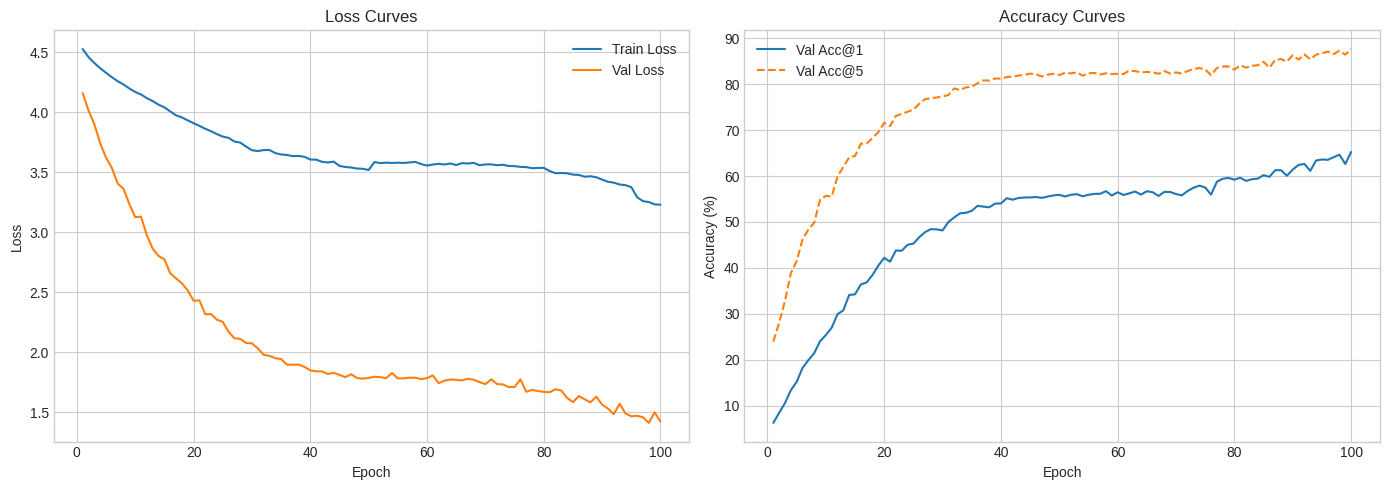

In [3]:
import torch
import matplotlib.pyplot as plt
import os

checkpoint_path = "/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100.pth"
save_chart_path = os.path.join(os.path.dirname(checkpoint_path), "imagenet100_training_chart.png")

if not os.path.exists(checkpoint_path):
    raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

checkpoint = torch.load(checkpoint_path, map_location='cpu')
history = checkpoint.get('history', None)
if history is None:
    raise RuntimeError("Checkpoint has no history. Train first.")

epochs = range(1, len(history['train_loss']) + 1)

plt.style.use('seaborn-v0_8-whitegrid')
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(epochs, history['train_loss'], label='Train Loss')
ax1.plot(epochs, history['val_loss'], label='Val Loss')
ax1.set_title('Loss Curves')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(epochs, history['val_acc1'], label='Val Acc@1')
ax2.plot(epochs, history['val_acc5'], label='Val Acc@5', linestyle='--')
ax2.set_title('Accuracy Curves')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.legend()

plt.tight_layout()
plt.savefig(save_chart_path, dpi=300)
print(f"Saved chart: {save_chart_path}")


# Inference Test

In [28]:
%%writefile inference_mambavision.py
import os
import sys
import json
from pathlib import Path

import torch
import torch.nn as nn
import torch.nn.functional as F
from PIL import Image
import torchvision.transforms as transforms

sys.path.insert(0, './MambaVision')
import mambavision.models.mamba_vision as mv


def main():
    data_root = Path('/content/data/imagenet100')
    checkpoint_path = '/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100.pth'
    best_checkpoint_path = '/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100_best.pth'
    labels_json = data_root / 'Labels.json'
    if os.path.exists(best_checkpoint_path):
        print(f'Using best model checkpoint: {best_checkpoint_path}')
        checkpoint_path = best_checkpoint_path
    device = 'cuda' if torch.cuda.is_available() else 'cpu'

    if not data_root.exists():
        raise FileNotFoundError(f'Missing data root: {data_root}')
    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f'Missing checkpoint: {checkpoint_path}')

    val_dir = data_root / 'val'
    if not val_dir.exists():
        val_candidates = sorted([p for p in data_root.iterdir() if p.is_dir() and p.name.startswith('val')])
        if not val_candidates:
            raise RuntimeError('No val/val.X directory found')
        val_dir = val_candidates[0]

    # Pick one sample image from validation split
    image_candidates = list(val_dir.rglob('*.JPEG'))
    if not image_candidates:
        image_candidates = list(val_dir.rglob('*.jpg'))
    if not image_candidates:
        raise RuntimeError('No validation image found for inference demo')
    image_path = image_candidates[0]

    synset_to_name = {}
    if labels_json.exists():
        synset_to_name = json.loads(labels_json.read_text(encoding='utf-8'))

    transform = transforms.Compose([
        transforms.Resize(256, interpolation=transforms.InterpolationMode.BICUBIC),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])

    image = Image.open(image_path).convert('RGB')
    x = transform(image).unsqueeze(0).to(device)

    if hasattr(mv, 'mamba_vision_T'):
        model = mv.mamba_vision_T(pretrained=False)
    elif hasattr(mv, 'mamba_vision_T1'):
        model = mv.mamba_vision_T1(pretrained=False)
    else:
        model = mv.mamba_vision_T2(pretrained=False)

    ckpt = torch.load(checkpoint_path, map_location=device)
    num_classes = ckpt.get('meta', {}).get('num_classes', 100)
    if hasattr(model, 'head'):
        model.head = nn.Linear(model.head.in_features, num_classes)
    model.to(device)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()

    with torch.no_grad():
        probs = F.softmax(model(x)[0], dim=0)
        top3_probs, top3_idx = torch.topk(probs, 3)

    print('=' * 60)
    print(f'Image: {image_path}')
    print('Top-3 predictions:')

    # Try to map idx -> synset via sorted train synset order used in training
    train_dirs = sorted([p for p in data_root.iterdir() if p.is_dir() and p.name.startswith('train')])
    synsets = sorted({p.name for d in train_dirs for p in d.iterdir() if p.is_dir()})

    for i in range(3):
        cls_idx = top3_idx[i].item()
        prob = top3_probs[i].item() * 100
        synset = synsets[cls_idx] if cls_idx < len(synsets) else f'class_{cls_idx}'
        readable = synset_to_name.get(synset, synset)
        print(f'{i+1}. idx={cls_idx:<3} synset={synset:<12} prob={prob:6.2f}%  name={readable}')

    print('=' * 60)


if __name__ == '__main__':
    main()

Overwriting inference_mambavision.py


In [29]:
!py310/bin/python inference_mambavision.py

/content/py310/lib/python3.10/site-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/py310/lib/python3.10/site-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
Using best model checkpoint: /content/drive/MyDrive/MambaVision/mambavision_T_imagenet100_best.pth
Image: /content/data/imagenet100/val.X/n01753488/ILSVRC2012_val_00046193.JPEG
Top-3 predictions:
1. idx=45  synset=n01756291    prob= 44.01%  name=sidewinder, horned rattlesnake, Crotalus cerastes
2. idx=43  synset=n01753488    prob= 24.71%  name=horned viper, cerastes, sand viper, horned asp, Cerastes cornutus
3. idx=44  synset=n01755581    prob=

# Report final metrics (from training checkpoint history)

In [30]:
%%writefile eval_mambavision.py
import os
import torch


def main():
    checkpoint_path = "/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100.pth"
    best_checkpoint_path = "/content/drive/MyDrive/MambaVision/mambavision_T_imagenet100_best.pth"

    if os.path.exists(best_checkpoint_path):
        print(f'Loading best checkpoint: {best_checkpoint_path}')
        checkpoint_path = best_checkpoint_path

    if not os.path.exists(checkpoint_path):
        raise FileNotFoundError(f"Missing checkpoint: {checkpoint_path}")

    ckpt = torch.load(checkpoint_path, map_location='cpu')
    history = ckpt.get('history', {})
    meta = ckpt.get('meta', {})

    print('=' * 80)
    print('MambaVision ImageNet100 report (VAL ONLY)')
    print('=' * 80)

    print(f"Model              : {meta.get('model_name', 'unknown')}")
    print(f"Num classes        : {meta.get('num_classes', 'unknown')}")
    print(f"Train subset ratio : {meta.get('train_subset_ratio', 'unknown')}")

    if history and len(history.get('val_acc1', [])) > 0:
        idx = len(history['val_acc1']) - 1

        print(f"Epochs trained     : {len(history.get('train_loss', []))}")
        print(f"Final val Acc@1    : {history['val_acc1'][idx]:.2f}")
        print(f"Final val Acc@5    : {history['val_acc5'][idx]:.2f}")
    else:
        print('No validation history found in checkpoint.')


if __name__ == '__main__':
    main()

Overwriting eval_mambavision.py


In [31]:
!py310/bin/python eval_mambavision.py

Loading best checkpoint: /content/drive/MyDrive/MambaVision/mambavision_T_imagenet100_best.pth
MambaVision ImageNet100 report (VAL ONLY)
Model              : mamba_vision_T
Num classes        : 100
Train subset ratio : 0.4
Epochs trained     : 100
Final val Acc@1    : 65.24
Final val Acc@5    : 87.64
